# **Import Data**

In [ ]:
import pandas as pd
import numpy as np
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_excel('/content/drive/MyDrive/scrapped_data_deepseek.xlsx')

In [ ]:
data.head()

,reviewId,userName,at,content
0,0f35b073-1783-4d48-9e11-51f640dc4d4e,Pengguna Google,2025-08-07 09:58:48,bagus bagus bagus
1,d8199c9c-561c-4c85-b1e4-fee115b09e11,Pengguna Google,2025-08-07 08:48:13,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸
2,97802895-8d10-4a73-9384-bdcd180331cf,Pengguna Google,2025-08-07 02:06:17,Very Bad AI stupid AI Merasa Paling Benar Sendiri
3,b0487f7f-8bb1-4beb-b552-f6d5d897d949,Pengguna Google,2025-08-06 21:34:57,"Halo Deepseek, Tolong diperbaiki dan tingkatka..."
4,ed7b960f-fad8-40f2-ac03-b68f6b99223c,Pengguna Google,2025-08-06 12:21:55,sangat membantu


In [ ]:
df = pd.DataFrame(data[['content']])
df.head()

,content
0,bagus bagus bagus
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka..."
4,sangat membantu


# **Delete Duplicate Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  2325 non-null   object
dtypes: object(1)
memory usage: 18.3+ KB


In [ ]:
df.drop_duplicates(subset='content', keep='first', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2237 entries, 0 to 2324
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  2237 non-null   object
dtypes: object(1)
memory usage: 35.0+ KB


# **Preprocessing Data (Modify)**

## Sentence Splitting (Pemisahan Kalimat)

In [ ]:
import spacy

try:
  nlp = spacy.load("xx_ent_wiki_sm")
except:
  !python -m spacy download xx_ent_wiki_sm
  nlp = spacy.load("xx_ent_wiki_sm")

nlp.add_pipe('sentencizer')

# Function untuk melakukan pemisahan kalimat menggunakan spaCy
def split_sentences(text):
  if isinstance(text, str):
    doc = nlp(text)
    return [sent.text for sent in doc.sents]
  else:
    return []

df['sentences'] = df['content'].apply(split_sentences)

df.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 63.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


,content,sentences
0,bagus bagus bagus,[bagus bagus bagus]
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,[DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥...
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,[Very Bad AI stupid AI Merasa Paling Benar Sen...
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...","[Halo Deepseek, Tolong diperbaiki dan tingkatk..."
4,sangat membantu,[sangat membantu]


In [ ]:
# Save Data
df.to_excel('sentences_data.xlsx', index=False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Ratakan daftar kalimat menjadi baris-baris individual
sentences_list = [sentence for sentences_per_review in df['sentences'] for sentence in sentences_per_review]

# Buat DataFrame baru dengan kalimat-kalimat tersebut
df_new_review = pd.DataFrame(sentences_list, columns=['sentence'])

# Tampilkan beberapa baris pertama dari DataFrame baru
display(df_new_review.head())

# Tampilkan info DataFrame baru
df_new_review.info()

,sentence
0,bagus bagus bagus
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka..."
4,sangat membantu


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  3186 non-null   object
dtypes: object(1)
memory usage: 25.0+ KB


In [ ]:
# Save data
df_new_review.to_excel('new_review_data.xlsx', index=False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cleaning (Pembersihan Teks)

In [ ]:
df_new_review = pd.read_excel('/content/drive/MyDrive/new_review_data.xlsx')

In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return text

    # Hapus emoji
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub("", text)

    # Hapus simbol selain huruf, angka, spasi
    text = re.sub(r"[^0-9A-Za-z\s]", "", text)

    # Hapus angka
    text = re.sub(r"\d+", "", text)

    # Rapikan spasi
    text = " ".join(text.split())

    return text

df_new_review["cleaning"] = df_new_review["sentence"].apply(clean_text)

In [ ]:
df_new_review.head(10)

,sentence,cleaning
0,bagus bagus bagus,bagus bagus bagus
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,DeepSeek hebat luar biasa
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,Very Bad AI stupid AI Merasa Paling Benar Sendiri
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",Halo Deepseek Tolong diperbaiki dan tingkatkan...
4,sangat membantu,sangat membantu
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,Tambahkan bahasa indonesia
6,"sangat membantu dan literasinya komplit, terim...",sangat membantu dan literasinya komplit terima...
7,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...
8,dan tolong ... privasi user ... tetap dijaga (...,dan tolong privasi user tetap dijaga itu sebag...
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...


## Case Folding (Lowercasing)


In [ ]:
def to_lower(text):
    return text.lower() if isinstance(text, str) else text

df_new_review["case_folding"] = df_new_review["cleaning"].apply(to_lower)
df_new_review.head(10)


,sentence,cleaning,case_folding
0,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,DeepSeek hebat luar biasa,deepseek hebat luar biasa
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,Very Bad AI stupid AI Merasa Paling Benar Sendiri,very bad ai stupid ai merasa paling benar sendiri
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",Halo Deepseek Tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...
4,sangat membantu,sangat membantu,sangat membantu
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,Tambahkan bahasa indonesia,tambahkan bahasa indonesia
6,"sangat membantu dan literasinya komplit, terim...",sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...
7,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...
8,dan tolong ... privasi user ... tetap dijaga (...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...


## Normalization (Mengubah kata tidak baku ke baku)

In [ ]:
def normalize_words(text, dictionary_nonstandard):
    # Jika bukan string, kembalikan nilai kosong sesuai format
    if not isinstance(text, str):
        return "", [], [], []

    tokens = text.split()

    processed_sentence = []      # kalimat setelah diganti
    list_standard = []           # kata baku hasil penggantian
    list_replaced = []           # kata tidak baku yang diganti
    replaced_hash = []           # hash kata tidak baku

    for token in tokens:
        # cek apakah token ada di kamus
        if token in dictionary_nonstandard:
            candidate = dictionary_nonstandard[token]

            # validasi kata baku (hanya huruf dan spasi)
            if isinstance(candidate, str) and all(ch.isalpha() or ch.isspace() for ch in candidate):
                processed_sentence.append(candidate)
                list_standard.append(candidate)
                list_replaced.append(token)
                replaced_hash.append(hash(token))
            else:
                # jika tidak valid, pakai kata asli
                processed_sentence.append(token)
        else:
            processed_sentence.append(token)

    # gabungkan menjadi kalimat
    normalized_text = " ".join(processed_sentence)

    return normalized_text, list_standard, list_replaced, replaced_hash


In [ ]:
# Memuat data kamus dari file Excel
df_kamus = pd.read_excel('/content/drive/MyDrive/kamuskatabaku.xlsx')

# Membentuk kamus menggunakan iterrows (bukan zip)
kamus_nonbaku = {
    row['tidak_baku']: row['kata_baku']
    for _, row in df_kamus.iterrows()
}

df_kamus.head(5)

,tidak_baku,kata_baku
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [ ]:
# Terapkan normalisasi
normalize_output = df_new_review['case_folding'].apply(
    lambda teks: normalize_words(teks, kamus_nonbaku)
)

# Memecah tuple menjadi 4 kolom terpisah
df_new_review[['normalized', 'kata_baku', 'kata_tidak_baku', 'hash_tidak_baku']] = (
    pd.DataFrame(normalize_output.tolist(), index=df_new_review.index)
)

df_new_review = df_new_review.loc[:, ['sentence', 'cleaning', 'case_folding', 'normalized']].copy()

df_new_review.head(10)


,sentence,cleaning,case_folding,normalized
0,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,DeepSeek hebat luar biasa,deepseek hebat luar biasa,deepseek hebat luar biasa
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,Very Bad AI stupid AI Merasa Paling Benar Sendiri,very bad ai stupid ai merasa paling benar sendiri,very bad ai stupid ai merasa paling benar sendiri
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",Halo Deepseek Tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...
4,sangat membantu,sangat membantu,sangat membantu,sangat membantu
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,Tambahkan bahasa indonesia,tambahkan bahasa indonesia,tambahkan bahasa indonesia
6,"sangat membantu dan literasinya komplit, terim...",sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...
7,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan ya lebih b...
8,dan tolong ... privasi user ... tetap dijaga (...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yang saya pakai kar...


## Tokenizing (Memecah kalimat menjadi kata-kata)

In [ ]:
def word_tokenizer(text):
    if isinstance(text, str):
        # memecah teks menjadi token dengan penghilangan spasi ekstra
        return text.strip().split()
    else:
        return []

df_new_review['tokenized'] = df_new_review['normalized'].apply(word_tokenizer)
df_new_review.head(10)

,sentence,cleaning,case_folding,normalized,tokenized
0,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,"[bagus, bagus, bagus]"
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,DeepSeek hebat luar biasa,deepseek hebat luar biasa,deepseek hebat luar biasa,"[deepseek, hebat, luar, biasa]"
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,Very Bad AI stupid AI Merasa Paling Benar Sendiri,very bad ai stupid ai merasa paling benar sendiri,very bad ai stupid ai merasa paling benar sendiri,"[very, bad, ai, stupid, ai, merasa, paling, be..."
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",Halo Deepseek Tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,"[halo, deepseek, tolong, diperbaiki, dan, ting..."
4,sangat membantu,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]"
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,Tambahkan bahasa indonesia,tambahkan bahasa indonesia,tambahkan bahasa indonesia,"[tambahkan, bahasa, indonesia]"
6,"sangat membantu dan literasinya komplit, terim...",sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,"[sangat, membantu, dan, literasinya, komplit, ..."
7,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan ya lebih b...,"[mengharapkan, agar, deepseek, ke, depan, ya, ..."
8,dan tolong ... privasi user ... tetap dijaga (...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,"[dan, tolong, privasi, user, tetap, dijaga, it..."
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yang saya pakai kar...,"[deep, seek, ai, paling, mantap, yang, saya, p..."


## Stopword Removal (Menghapus kata tidak penting)

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def stopwords(text):
  return [word for word in text if word not in stop_words]

df_new_review['stopword'] = df_new_review['tokenized'].apply(lambda x: stopwords (x))
df_new_review.head(10)

,sentence,cleaning,case_folding,normalized,tokenized,stopword
0,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,"[bagus, bagus, bagus]","[bagus, bagus, bagus]"
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,DeepSeek hebat luar biasa,deepseek hebat luar biasa,deepseek hebat luar biasa,"[deepseek, hebat, luar, biasa]","[deepseek, hebat]"
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,Very Bad AI stupid AI Merasa Paling Benar Sendiri,very bad ai stupid ai merasa paling benar sendiri,very bad ai stupid ai merasa paling benar sendiri,"[very, bad, ai, stupid, ai, merasa, paling, be...","[very, bad, ai, stupid, ai]"
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",Halo Deepseek Tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,"[halo, deepseek, tolong, diperbaiki, dan, ting...","[halo, deepseek, tolong, diperbaiki, tingkatka..."
4,sangat membantu,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]",[membantu]
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,Tambahkan bahasa indonesia,tambahkan bahasa indonesia,tambahkan bahasa indonesia,"[tambahkan, bahasa, indonesia]","[tambahkan, bahasa, indonesia]"
6,"sangat membantu dan literasinya komplit, terim...",sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,"[sangat, membantu, dan, literasinya, komplit, ...","[membantu, literasinya, komplit, terimakasih]"
7,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan ya lebih b...,"[mengharapkan, agar, deepseek, ke, depan, ya, ...","[mengharapkan, deepseek, ya, kalah, upgrade, a..."
8,dan tolong ... privasi user ... tetap dijaga (...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,"[dan, tolong, privasi, user, tetap, dijaga, it...","[tolong, privasi, user, dijaga, komitmen, deve..."
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yang saya pakai kar...,"[deep, seek, ai, paling, mantap, yang, saya, p...","[deep, seek, ai, mantap, pakai, belajar, ilmu,..."


## Stemming (Mengubah kata ke bentuk dasarnya)

In [ ]:
!pip install Sastrawi

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi stemmer bahasa Indonesia dari Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi untuk melakukan stemming pada list kata
def apply_stemming(token_list):
    return [stemmer.stem(word) for word in token_list]

# Terapkan stemming
df_new_review['stemmed'] = df_new_review['stopword'].apply(lambda tokens: ' '.join(apply_stemming(tokens)))

# Tampilkan 10 baris pertama hasilnya
df_new_review.head(10)

,sentence,cleaning,case_folding,normalized,tokenized,stopword,stemmed
0,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,bagus bagus bagus,"[bagus, bagus, bagus]","[bagus, bagus, bagus]",bagus bagus bagus
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,DeepSeek hebat luar biasa,deepseek hebat luar biasa,deepseek hebat luar biasa,"[deepseek, hebat, luar, biasa]","[deepseek, hebat]",deepseek hebat
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,Very Bad AI stupid AI Merasa Paling Benar Sendiri,very bad ai stupid ai merasa paling benar sendiri,very bad ai stupid ai merasa paling benar sendiri,"[very, bad, ai, stupid, ai, merasa, paling, be...","[very, bad, ai, stupid, ai]",very bad ai stupid ai
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",Halo Deepseek Tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,halo deepseek tolong diperbaiki dan tingkatkan...,"[halo, deepseek, tolong, diperbaiki, dan, ting...","[halo, deepseek, tolong, diperbaiki, tingkatka...",halo deepseek tolong baik tingkat respon hasil...
4,sangat membantu,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]",[membantu],bantu
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,Tambahkan bahasa indonesia,tambahkan bahasa indonesia,tambahkan bahasa indonesia,"[tambahkan, bahasa, indonesia]","[tambahkan, bahasa, indonesia]",tambah bahasa indonesia
6,"sangat membantu dan literasinya komplit, terim...",sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,sangat membantu dan literasinya komplit terima...,"[sangat, membantu, dan, literasinya, komplit, ...","[membantu, literasinya, komplit, terimakasih]",bantu literasinya komplit terimakasih
7,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan nya lebih ...,mengharapkan agar deepseek ke depan ya lebih b...,"[mengharapkan, agar, deepseek, ke, depan, ya, ...","[mengharapkan, deepseek, ya, kalah, upgrade, a...",harap deepseek ya kalah upgrade aplikasi
8,dan tolong ... privasi user ... tetap dijaga (...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,dan tolong privasi user tetap dijaga itu sebag...,"[dan, tolong, privasi, user, tetap, dijaga, it...","[tolong, privasi, user, dijaga, komitmen, deve...",tolong privasi user jaga komitmen developer user
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yg saya pake karena...,deep seek ai paling mantap yang saya pakai kar...,"[deep, seek, ai, paling, mantap, yang, saya, p...","[deep, seek, ai, mantap, pakai, belajar, ilmu,...",deep seek ai mantap pakai ajar ilmu gampang


In [ ]:
#Save file excel
df_new_review.to_excel('data_preprocessing_raw.xlsx', index=False)

## Hapus Data Bernilai Kosong

In [ ]:
import pandas as pd

df_new_review = pd.read_excel('/content/drive/MyDrive/data_preprocessing_raw.xlsx')
df_new_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sentence      3186 non-null   object
 1   cleaning      3165 non-null   object
 2   case_folding  3165 non-null   object
 3   normalized    3165 non-null   object
 4   tokenized     3186 non-null   object
 5   stopword      3186 non-null   object
 6   stemmed       3129 non-null   object
dtypes: object(7)
memory usage: 174.4+ KB


In [ ]:
df_new_review = df_new_review.dropna(subset=['stemmed'])
df_new_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 0 to 3185
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sentence      3129 non-null   object
 1   cleaning      3129 non-null   object
 2   case_folding  3129 non-null   object
 3   normalized    3129 non-null   object
 4   tokenized     3129 non-null   object
 5   stopword      3129 non-null   object
 6   stemmed       3129 non-null   object
dtypes: object(7)
memory usage: 195.6+ KB


In [ ]:
#Save file excel
df_new_review.to_excel('data_preprocessing.xlsx', index=False)

## Pelabelan dengan Lexicon Based

In [ ]:
df_new_review = pd.read_excel('/content/drive/MyDrive/data_preprocessing.xlsx')
df_new_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sentence      3129 non-null   object
 1   cleaning      3129 non-null   object
 2   case_folding  3129 non-null   object
 3   normalized    3129 non-null   object
 4   tokenized     3129 non-null   object
 5   stopword      3129 non-null   object
 6   stemmed       3129 non-null   object
dtypes: object(7)
memory usage: 171.2+ KB


In [ ]:
df_new_review = pd.DataFrame(df_new_review[['stemmed']])
df_new_review.head(5)

,stemmed
0,bagus bagus bagus
1,deepseek hebat
2,very bad ai stupid ai
3,halo deepseek tolong baik tingkat respon hasil...
4,bantu


In [ ]:
import pandas as pd

# Kamus Lexicon
pos_df = pd.read_csv("/content/drive/MyDrive/positive_lex.tsv", sep="\t")[["word", "weight"]]
neg_df = pd.read_csv("/content/drive/MyDrive/negative_lex.tsv", sep="\t")[["word", "weight"]]

merged_lex = pd.concat([pos_df, neg_df], ignore_index=True)

LEXICON = dict(zip(merged_lex["word"], merged_lex["weight"]))

# Fungsi perhtiungan lexicon
def compute_sentiment(text):
    if not isinstance(text, str):
        return 0, "Netral"

    tokens = text.split()
    score = sum(LEXICON.get(tok, 0) for tok in tokens)

    if score > 0:
        label = "Positif"
    elif score < 0:
        label = "Negatif"
    else:
        label = "Netral"

    return score, label

df_new_review[["score", "label"]] = df_new_review["stemmed"].apply(lambda t: pd.Series(compute_sentiment(t)))

df_new_review.head(20)

,stemmed,score,label
0,bagus bagus bagus,6,Positif
1,deepseek hebat,0,Netral
2,very bad ai stupid ai,-4,Negatif
3,halo deepseek tolong baik tingkat respon hasil...,23,Positif
4,bantu,-4,Negatif
5,tambah bahasa indonesia,-1,Negatif
6,bantu literasinya komplit terimakasih,1,Positif
7,harap deepseek ya kalah upgrade aplikasi,-7,Negatif
8,tolong privasi user jaga komitmen developer user,-5,Negatif
9,deep seek ai mantap pakai ajar ilmu gampang,3,Positif


/tmp/ipython-input-282855391.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette={'Positif': 'skyblue', 'Negatif': 'salmon', 'Netral': 'gray'})


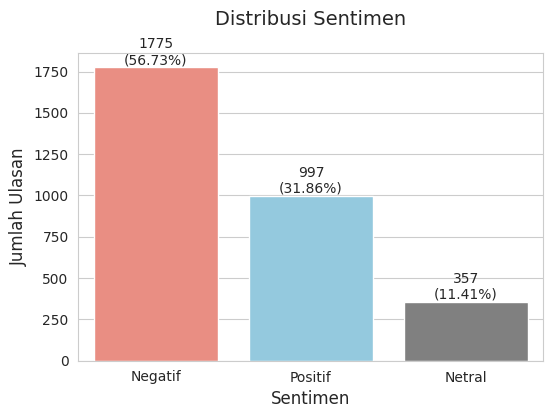

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df_new_review['label'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette={'Positif': 'skyblue', 'Negatif': 'salmon', 'Netral': 'gray'})
plt.title('Distribusi Sentimen', fontsize=14, pad=20)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

total = len(df_new_review['label'])

for i, count in enumerate(sentiment_count.values):
  percentage = f'{100 * count / total:.2f}%'
  ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()


In [ ]:
#Pilih label positif dan negatif saja
df_new_review = df_new_review[df_new_review['label'].isin(['Positif', 'Negatif'])]
df_new_review.head()

,stemmed,score,label
0,bagus bagus bagus,6,Positif
2,very bad ai stupid ai,-4,Negatif
3,halo deepseek tolong baik tingkat respon hasil...,23,Positif
4,bantu,-4,Negatif
5,tambah bahasa indonesia,-1,Negatif


/tmp/ipython-input-2528609713.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette={'Positif': 'skyblue', 'Negatif': 'salmon'})


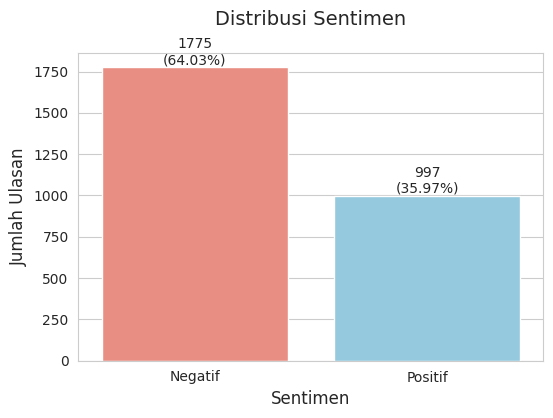

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df_new_review['label'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette={'Positif': 'skyblue', 'Negatif': 'salmon'})
plt.title('Distribusi Sentimen', fontsize=14, pad=20)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

total = len(df_new_review['label'])

for i, count in enumerate(sentiment_count.values):
  percentage = f'{100 * count / total:.2f}%'
  ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
df_new_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2772 entries, 0 to 3128
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   stemmed  2772 non-null   object
 1   score    2772 non-null   int64 
 2   label    2772 non-null   object
dtypes: int64(1), object(2)
memory usage: 86.6+ KB


In [ ]:
#Save file excel
df_new_review.to_excel('data_label_pos_neg.xlsx', index=False)

In [ ]:
!pip install wordcloud matplotlib

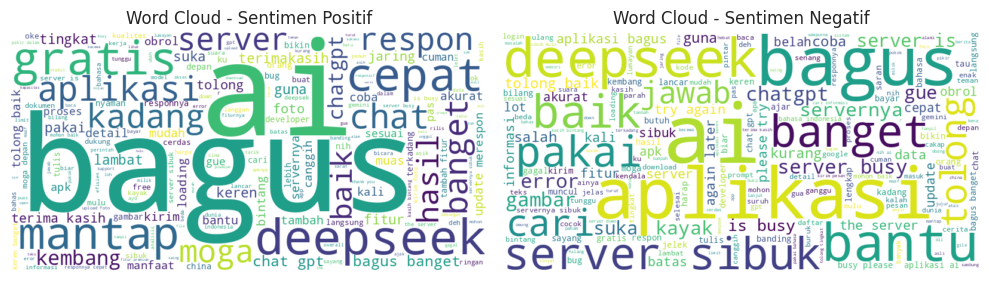

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Custom stopwords untuk word clouds positif dan negatif
positive_stopwords = {"ya", "sih"}
negative_stopwords = {"ya", "sih"}

# Filter data untuk sentimen positif dan negatif
positive_reviews = df_new_review[df_new_review['label'] == 'Positif']
negative_reviews = df_new_review[df_new_review['label'] == 'Negatif']

# Gabungkan teks 'stemmed' untuk setiap sentimen
positive_text = " ".join(review for review in positive_reviews['stemmed'].dropna())
negative_text = " ".join(review for review in negative_reviews['stemmed'].dropna())

# Generate Word Cloud Sentimen Positif
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', stopwords=positive_stopwords).generate(positive_text)

# Generate Word Cloud Sentimen Negatif
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', stopwords=negative_stopwords).generate(negative_text)

# Menampilkan word clouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Sentimen Positif')
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Sentimen Negatif')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from collections import Counter

# Tokenize and filter stopwords
positive_tokens = [word for word in positive_text.split() if word.lower() not in positive_stopwords]
negative_tokens = [word for word in negative_text.split() if word.lower() not in negative_stopwords]

# Count word frequencies
positive_counts = Counter(positive_tokens)
negative_counts = Counter(negative_tokens)

# Create DataFrames
df_positive_freq = pd.DataFrame(positive_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)
df_negative_freq = pd.DataFrame(negative_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

print("Top Positive Words:")
print(df_positive_freq.head(20))

print("\nTop Negative Words:")
print(df_negative_freq.head(20))

Top Positive Words:
         Word  Frequency
0       bagus        303
8          ai        251
61     banget        102
2    deepseek         96
25       chat         95
28      cepat         93
24     server         85
53     gratis         85
38     mantap         81
4        baik         71
58       moga         60
15   aplikasi         56
105    kadang         53
19      fitur         51
3      tolong         49
55        gpt         48
6      respon         47
63      keren         46
52      kasih         45
117      foto         45

Top Negative Words:
          Word  Frequency
2           ai        363
57      server        331
12    aplikasi        323
34       bagus        298
53        baik        188
45       sibuk        181
4        bantu        167
9     deepseek        159
25      banget        152
13      tolong        148
164       busy        148
83       pakai        119
278       cari         88
44   servernya         86
47     chatgpt         73
6       bahasa    

# **Modeling**

In [ ]:
import pandas as pd
import numpy as np
import re

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/data_label_pos_neg.xlsx')
data.head(5)

,stemmed,score,label
0,bagus bagus bagus,6,Positif
1,very bad ai stupid ai,-4,Negatif
2,halo deepseek tolong baik tingkat respon hasil...,23,Positif
3,bantu,-4,Negatif
4,tambah bahasa indonesia,-1,Negatif


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   stemmed  2772 non-null   object
 1   score    2772 non-null   int64 
 2   label    2772 non-null   object
dtypes: int64(1), object(2)
memory usage: 65.1+ KB


In [ ]:
label_count = data['label'].value_counts()
label_count

,count
label,
Negatif,1775
Positif,997


## Data split, TF IDF, SMOTE

Distribusi label sebelum SMOTE (Train Set):
label
Negatif    1420
Positif     797
Name: count, dtype: int64

Distribusi label sesudah SMOTE (Train Set):
label
Positif    1420
Negatif    1420
Name: count, dtype: int64


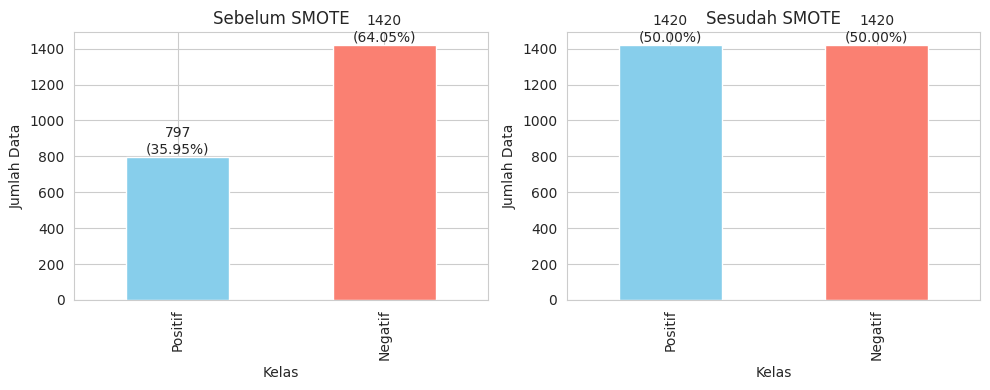

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Target variable
y = data['label']

# List of raw text
df_list = data['stemmed'].fillna('').tolist()

# ===== 1. Split raw text into train/test =====
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_list, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribusi label sebelum SMOTE (Train Set):")
print(y_train.value_counts())

# ===== 2. TF-IDF =====
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# ===== 3. SMOTE on TF-IDF train set =====
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("\nDistribusi label sesudah SMOTE (Train Set):")
print(y_train_smote.value_counts())

# ===== 4. Visualisasi distribusi =====
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Urutan label yang konsisten
order = ['Positif', 'Negatif']

# Sebelum SMOTE
counts_before = y_train.value_counts().reindex(order)
counts_before.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title("Sebelum SMOTE")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Data")

total_before = counts_before.sum()
for i, count in enumerate(counts_before):
    pct = f"{100 * count / total_before:.2f}%"
    axes[0].text(i, count + 5, f"{count}\n({pct})", ha='center', va='bottom')

# Sesudah SMOTE
counts_after = y_train_smote.value_counts().reindex(order)
counts_after.plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_title("Sesudah SMOTE")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah Data")

total_after = counts_after.sum()
for i, count in enumerate(counts_after):
    pct = f"{100 * count / total_after:.2f}%"
    axes[1].text(i, count + 5, f"{count}\n({pct})", ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Assess

=== Sebelum SMOTE ===
Accuracy    : 0.9261
Precision   : 0.9392
Recall      : 0.8500
Specificity : 0.9690
F1 Score    : 0.8924

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9198    0.9690    0.9438       355
     Positif     0.9392    0.8500    0.8924       200

    accuracy                         0.9261       555
   macro avg     0.9295    0.9095    0.9181       555
weighted avg     0.9268    0.9261    0.9252       555



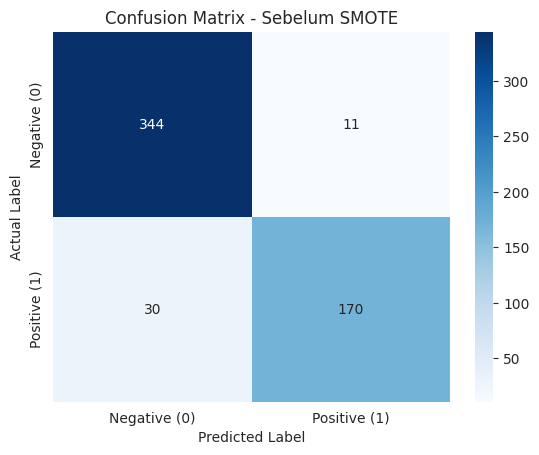

=== Sesudah SMOTE ===
Accuracy    : 0.9315
Precision   : 0.9402
Recall      : 0.8650
Specificity : 0.9690
F1 Score    : 0.9010

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9272    0.9690    0.9477       355
     Positif     0.9402    0.8650    0.9010       200

    accuracy                         0.9315       555
   macro avg     0.9337    0.9170    0.9244       555
weighted avg     0.9319    0.9315    0.9309       555



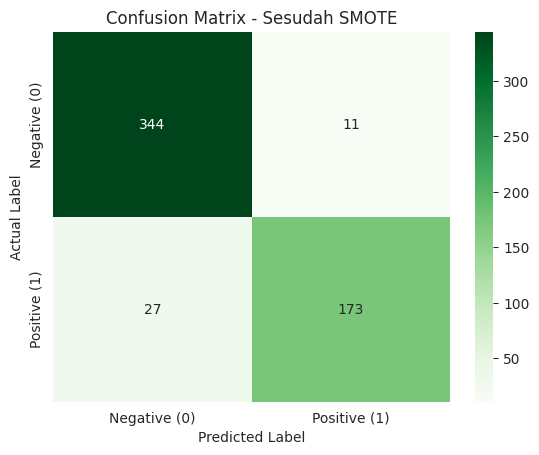

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_metrics(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"=== {title} ===")
    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"Specificity : {specificity:.4f}")
    print(f"F1 Score    : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues' if "Sebelum" in title else 'Greens',
        xticklabels=['Negative (0)', 'Positive (1)'],
        yticklabels=['Negative (0)', 'Positive (1)']
    )
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

# ===== 1. Train & Eval Sebelum SMOTE =====
svm_before = LinearSVC(random_state=42, max_iter=5000)
svm_before.fit(X_train_tfidf, y_train)
y_pred_before = svm_before.predict(X_test_tfidf)
evaluate_metrics(y_test, y_pred_before, "Sebelum SMOTE")

# ===== 2. Train & Eval Sesudah SMOTE =====
svm_after = LinearSVC(random_state=42, max_iter=5000)
svm_after.fit(X_train_smote, y_train_smote)
y_pred_after = svm_after.predict(X_test_tfidf)
evaluate_metrics(y_test, y_pred_after, "Sesudah SMOTE")


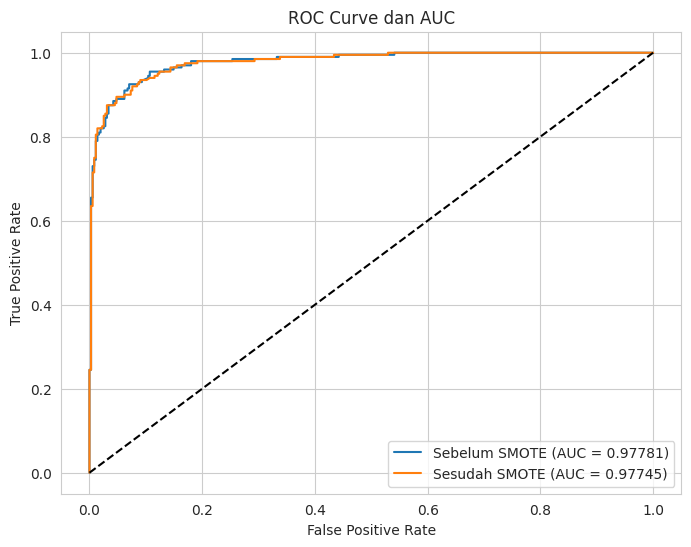

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Kalibrasi model sebelum SMOTE
frozen_model_before = FrozenEstimator(estimator=svm_before)
calibrated_before = CalibratedClassifierCV(frozen_model_before, method='sigmoid')
calibrated_before.fit(X_train_tfidf, y_train)

# Kalibrasi model sesudah SMOTE
frozen_model_after = FrozenEstimator(estimator=svm_after)
calibrated_after = CalibratedClassifierCV(frozen_model_after, method='sigmoid')
calibrated_after.fit(X_train_smote, y_train_smote)

# Probabilitas kelas positif
y_proba_before = calibrated_before.predict_proba(X_test_tfidf)[:, 1]
y_proba_after  = calibrated_after.predict_proba(X_test_tfidf)[:, 1]

# ROC curve
fpr_before, tpr_before, _ = roc_curve(y_test, y_proba_before, pos_label='Positif')
auc_before = auc(fpr_before, tpr_before)

fpr_after, tpr_after, _ = roc_curve(y_test, y_proba_after, pos_label='Positif')
auc_after = auc(fpr_after, tpr_after)

# Plot ROC–AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr_before, tpr_before, label=f"Sebelum SMOTE (AUC = {auc_before:.5f})")
plt.plot(fpr_after,  tpr_after,  label=f"Sesudah SMOTE (AUC = {auc_after:.5f})")
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve dan AUC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

def calculate_gmean(y_true, y_pred):
  """
  Calculates the Geometric Mean (G-Mean) for classification evaluation.

  Args:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.

  Returns:
    float: The calculated G-Mean score.
  """
  cm = confusion_matrix(y_true, y_pred)
  # Dengan asumsi klasifikasi biner dengan Negatif sebagai kelas negatif dan Positif sebagai kelas positif
  tn, fp, fn, tp = cm.ravel()

  specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
  sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

  gmean = np.sqrt(specificity * sensitivity)
  return gmean

# Hitung G-Mean untuk SVM tanpa SMOTE
gmean_before = calculate_gmean(y_test, y_pred_before)
print(f"G-Mean for SVM Before SMOTE: {gmean_before:.4f}")

# Hitung G-Mean untuk SVM dengan SMOTE
gmean_after = calculate_gmean(y_test, y_pred_after)
print(f"G-Mean for SVM After SMOTE: {gmean_after:.4f}")

G-Mean for SVM Before SMOTE: 0.9076
G-Mean for SVM After SMOTE: 0.9155


## Assess Baru Tabel CM (For Each Fold in Cross Validation)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

In [ ]:
X_text = data['stemmed'].fillna('').values
y = data['label'].values

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
def build_fold_table(y_true, y_pred, accuracy):
    rows = []

    for label in ['Negatif', 'Positif']:
        rows.append({
            'Kelas': label,
            'Precision': precision_score(y_true, y_pred, labels=[label], average='macro'),
            'Recall': recall_score(y_true, y_pred, labels=[label], average='macro'),
            'F1-Score': f1_score(y_true, y_pred, labels=[label], average='macro'),
            'Accuracy': accuracy
        })

    # Rata-rata per fold
    rows.append({
        'Kelas': 'Rata-rata',
        'Precision': np.mean([r['Precision'] for r in rows]),
        'Recall': np.mean([r['Recall'] for r in rows]),
        'F1-Score': np.mean([r['F1-Score'] for r in rows]),
        'Accuracy': accuracy
    })

    return pd.DataFrame(rows)


In [ ]:
fold_tables_before = []
summary_metrics_before = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_text, y), 1):
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = LinearSVC(random_state=42, max_iter=5000)
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)

    table = build_fold_table(y_test, y_pred, acc)
    fold_tables_before.append(table)

    summary_metrics_before.append(table.loc[table['Kelas'] == 'Rata-rata'])

    print(f"\n=== Fold {fold} — SVM Tanpa SMOTE ===")
    display(table.round(4))



=== Fold 1 — SVM Tanpa SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9351,0.9719,0.9532,0.9388
1,Positif,0.9462,0.8800,0.9119,0.9388
2,Rata-rata,0.9407,0.9260,0.9325,0.9388



=== Fold 2 — SVM Tanpa SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9435,0.9382,0.9408,0.9245
1,Positif,0.8911,0.9000,0.8955,0.9245
2,Rata-rata,0.9173,0.9191,0.9182,0.9245



=== Fold 3 — SVM Tanpa SMOTE ===


...

,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9286,0.9494,0.9389,0.9206
1,Positif,0.9053,0.8687,0.8866,0.9206
2,Rata-rata,0.9169,0.9091,0.9127,0.9206



=== Fold 9 — SVM Tanpa SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9322,0.9270,0.9296,0.9097
1,Positif,0.8700,0.8788,0.8744,0.9097
2,Rata-rata,0.9011,0.9029,0.9020,0.9097



=== Fold 10 — SVM Tanpa SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9337,0.9494,0.9415,0.9242
1,Positif,0.9062,0.8788,0.8923,0.9242
2,Rata-rata,0.9200,0.9141,0.9169,0.9242


In [ ]:
final_avg_before = pd.concat(summary_metrics_before).mean(numeric_only=True)
final_avg_table_before = pd.DataFrame([final_avg_before], index=['Rata-rata 5 Fold'])

print("\n=== Rata-Rata Keseluruhan (5 Fold) — SVM Tanpa SMOTE ===")
display(final_avg_table_before.round(4))



=== Rata-Rata Keseluruhan (5 Fold) — SVM Tanpa SMOTE ===


,Precision,Recall,F1-Score,Accuracy
Rata-rata 5 Fold,0.9164,0.9091,0.9123,0.9199


In [ ]:
fold_tables_after = []
summary_metrics_after = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_text, y), 1):
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

    model = LinearSVC(random_state=42, max_iter=5000)
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)

    table = build_fold_table(y_test, y_pred, acc)
    fold_tables_after.append(table)

    summary_metrics_after.append(table.loc[table['Kelas'] == 'Rata-rata'])

    print(f"\n=== Fold {fold} — SVM + SMOTE ===")
    display(table.round(4))



=== Fold 1 — SVM + SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9399,0.9663,0.9529,0.9388
1,Positif,0.9368,0.8900,0.9128,0.9388
2,Rata-rata,0.9384,0.9281,0.9329,0.9388



=== Fold 2 — SVM + SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9432,0.9326,0.9379,0.9209
1,Positif,0.8824,0.9000,0.8911,0.9209
2,Rata-rata,0.9128,0.9163,0.9145,0.9209



=== Fold 3 — SVM + SMOTE ===


...

,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9392,0.9551,0.9471,0.9314
1,Positif,0.9167,0.8889,0.9026,0.9314
2,Rata-rata,0.9279,0.9220,0.9248,0.9314



=== Fold 9 — SVM + SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9375,0.9270,0.9322,0.9134
1,Positif,0.8713,0.8889,0.8800,0.9134
2,Rata-rata,0.9044,0.9079,0.9061,0.9134



=== Fold 10 — SVM + SMOTE ===


,Kelas,Precision,Recall,F1-Score,Accuracy
0,Negatif,0.9379,0.9326,0.9352,0.917
1,Positif,0.8800,0.8889,0.8844,0.917
2,Rata-rata,0.9089,0.9107,0.9098,0.917


In [ ]:
final_avg_after = pd.concat(summary_metrics_after).mean(numeric_only=True)
final_avg_table_after = pd.DataFrame([final_avg_after], index=['Rata-rata 5 Fold'])

print("\n=== Rata-Rata Keseluruhan (5 Fold) — SVM + SMOTE ===")
display(final_avg_table_after.round(4))



=== Rata-Rata Keseluruhan (5 Fold) — SVM + SMOTE ===


,Precision,Recall,F1-Score,Accuracy
Rata-rata 5 Fold,0.9163,0.914,0.9148,0.9217


## Assess Baru Full CM (For Each Fold in Cross Validation)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt


def evaluate_fold(y_true, y_pred, y_score, fold, title):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n===== {title} | Fold {fold} =====")
    print("Confusion Matrix:")
    print([[tn, fp],
           [fn, tp]])

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # ROC & AUC
    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label='Positif')
    auc = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {title} (Fold {fold})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # G-Mean
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    gmean = np.sqrt(specificity * sensitivity)

    print(f"G-Mean : {gmean:.4f}")

    return cm, auc, gmean


===== SVM Tanpa SMOTE | Fold 1 =====
Confusion Matrix:
[[np.int64(173), np.int64(5)], [np.int64(12), np.int64(88)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9351    0.9719    0.9532       178
     Positif     0.9462    0.8800    0.9119       100

    accuracy                         0.9388       278
   macro avg     0.9407    0.9260    0.9325       278
weighted avg     0.9391    0.9388    0.9383       278



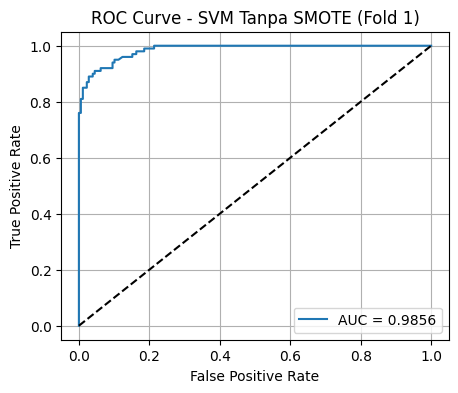

G-Mean : 0.9248

===== SVM Tanpa SMOTE | Fold 2 =====
Confusion Matrix:
[[np.int64(167), np.int64(11)], [np.int64(10), np.int64(90)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9435    0.9382    0.9408       178
     Positif     0.8911    0.9000    0.8955       100

    accuracy                         0.9245       278
   macro avg     0.9173    0.9191    0.9182       278
weighted avg     0.9246    0.9245    0.9245       278



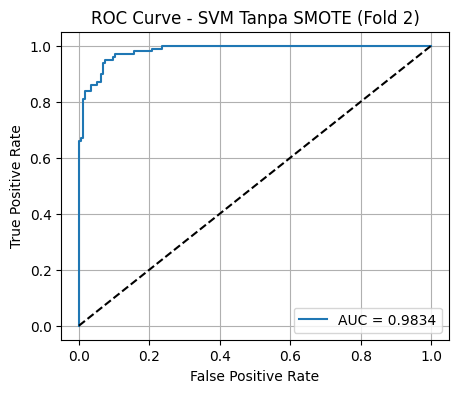

G-Mean : 0.9189

===== SVM Tanpa SMOTE | Fold 3 =====
Confusion Matrix:
[[np.int64(168), np.int64(9)], [np.int64(20), np.int64(80)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.8936    0.9492    0.9205       177
     Positif     0.8989    0.8000    0.8466       100

    accuracy                         0.8953       277
   macro avg     0.8962    0.8746    0.8836       277
weighted avg     0.8955    0.8953    0.8938       277



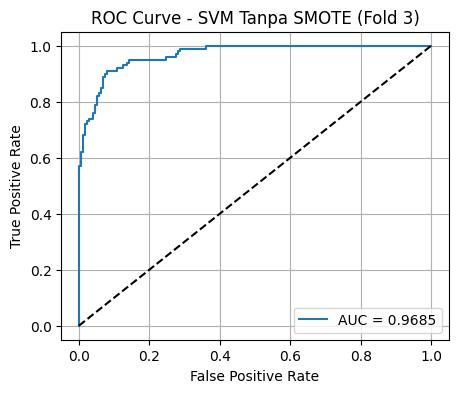

G-Mean : 0.8714

===== SVM Tanpa SMOTE | Fold 4 =====
Confusion Matrix:
[[np.int64(169), np.int64(8)], [np.int64(15), np.int64(85)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9185    0.9548    0.9363       177
     Positif     0.9140    0.8500    0.8808       100

    accuracy                         0.9170       277
   macro avg     0.9162    0.9024    0.9086       277
weighted avg     0.9169    0.9170    0.9163       277



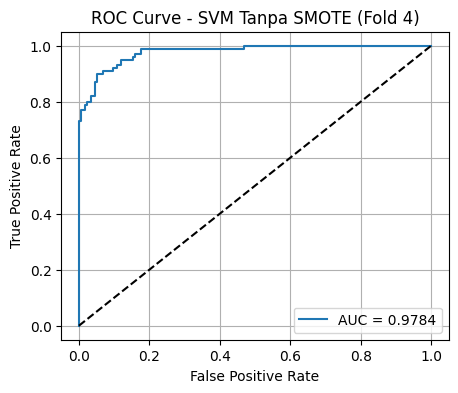

G-Mean : 0.9009

===== SVM Tanpa SMOTE | Fold 5 =====
Confusion Matrix:
[[np.int64(170), np.int64(7)], [np.int64(15), np.int64(85)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9189    0.9605    0.9392       177
     Positif     0.9239    0.8500    0.8854       100

    accuracy                         0.9206       277
   macro avg     0.9214    0.9052    0.9123       277
weighted avg     0.9207    0.9206    0.9198       277



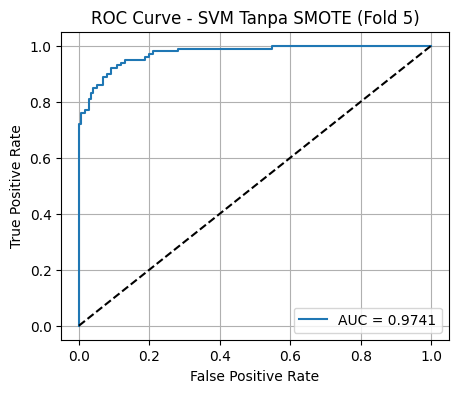

G-Mean : 0.9035

===== SVM Tanpa SMOTE | Fold 6 =====
Confusion Matrix:
[[np.int64(165), np.int64(12)], [np.int64(10), np.int64(90)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9429    0.9322    0.9375       177
     Positif     0.8824    0.9000    0.8911       100

    accuracy                         0.9206       277
   macro avg     0.9126    0.9161    0.9143       277
weighted avg     0.9210    0.9206    0.9207       277



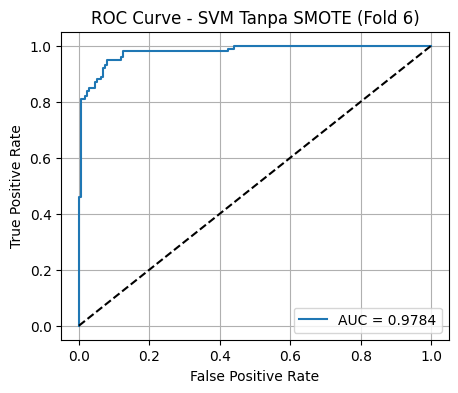

G-Mean : 0.9160

===== SVM Tanpa SMOTE | Fold 7 =====
Confusion Matrix:
[[np.int64(167), np.int64(10)], [np.int64(10), np.int64(90)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9435    0.9435    0.9435       177
     Positif     0.9000    0.9000    0.9000       100

    accuracy                         0.9278       277
   macro avg     0.9218    0.9218    0.9218       277
weighted avg     0.9278    0.9278    0.9278       277



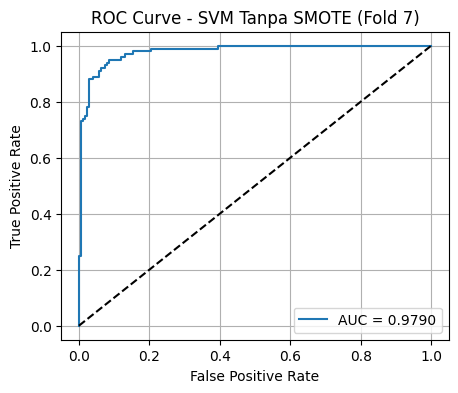

G-Mean : 0.9215

===== SVM Tanpa SMOTE | Fold 8 =====
Confusion Matrix:
[[np.int64(169), np.int64(9)], [np.int64(13), np.int64(86)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9286    0.9494    0.9389       178
     Positif     0.9053    0.8687    0.8866        99

    accuracy                         0.9206       277
   macro avg     0.9169    0.9091    0.9127       277
weighted avg     0.9202    0.9206    0.9202       277



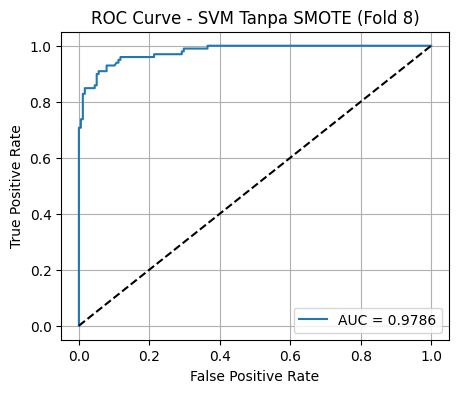

G-Mean : 0.9082

===== SVM Tanpa SMOTE | Fold 9 =====
Confusion Matrix:
[[np.int64(165), np.int64(13)], [np.int64(12), np.int64(87)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9322    0.9270    0.9296       178
     Positif     0.8700    0.8788    0.8744        99

    accuracy                         0.9097       277
   macro avg     0.9011    0.9029    0.9020       277
weighted avg     0.9100    0.9097    0.9098       277



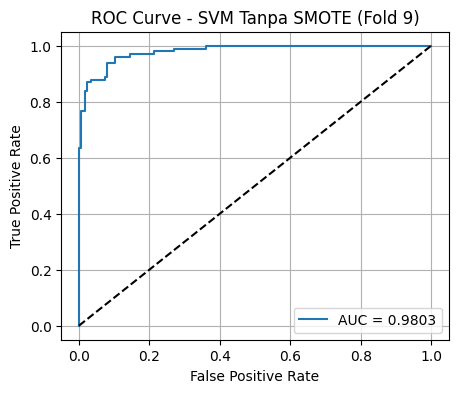

G-Mean : 0.9026

===== SVM Tanpa SMOTE | Fold 10 =====
Confusion Matrix:
[[np.int64(169), np.int64(9)], [np.int64(12), np.int64(87)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9337    0.9494    0.9415       178
     Positif     0.9062    0.8788    0.8923        99

    accuracy                         0.9242       277
   macro avg     0.9200    0.9141    0.9169       277
weighted avg     0.9239    0.9242    0.9239       277



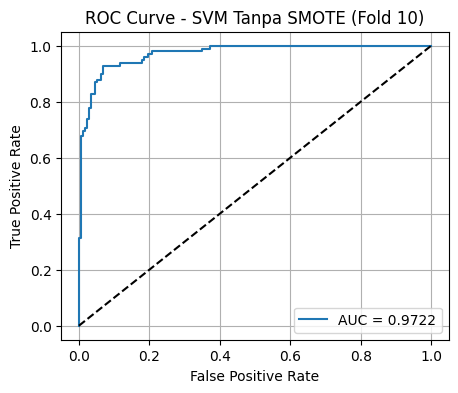

G-Mean : 0.9134


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import numpy as np

X_text = data['stemmed'].fillna('').values
y = data['label'].values

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cm_list_before, auc_list_before, gmean_list_before = [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_text, y), 1):
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    model = LinearSVC(random_state=42, max_iter=5000)
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)
    y_score = model.decision_function(X_test_tfidf)

    cm, auc, gmean = evaluate_fold(
        y_test, y_pred, y_score, fold, "SVM Tanpa SMOTE"
    )

    cm_list_before.append(cm)
    auc_list_before.append(auc)
    gmean_list_before.append(gmean)



===== SVM + SMOTE | Fold 1 =====
Confusion Matrix:
[[np.int64(172), np.int64(6)], [np.int64(11), np.int64(89)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9399    0.9663    0.9529       178
     Positif     0.9368    0.8900    0.9128       100

    accuracy                         0.9388       278
   macro avg     0.9384    0.9281    0.9329       278
weighted avg     0.9388    0.9388    0.9385       278



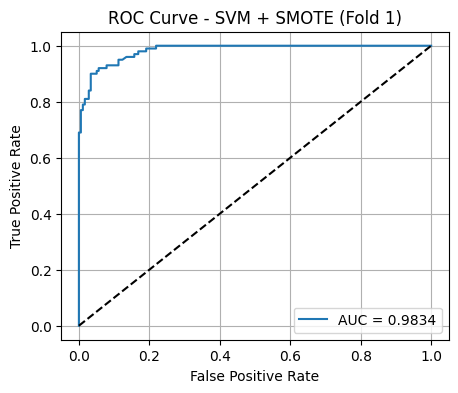

G-Mean : 0.9274

===== SVM + SMOTE | Fold 2 =====
Confusion Matrix:
[[np.int64(166), np.int64(12)], [np.int64(10), np.int64(90)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9432    0.9326    0.9379       178
     Positif     0.8824    0.9000    0.8911       100

    accuracy                         0.9209       278
   macro avg     0.9128    0.9163    0.9145       278
weighted avg     0.9213    0.9209    0.9210       278



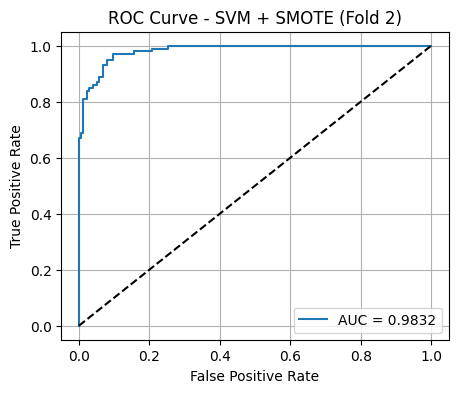

G-Mean : 0.9161

===== SVM + SMOTE | Fold 3 =====
Confusion Matrix:
[[np.int64(166), np.int64(11)], [np.int64(18), np.int64(82)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9022    0.9379    0.9197       177
     Positif     0.8817    0.8200    0.8497       100

    accuracy                         0.8953       277
   macro avg     0.8919    0.8789    0.8847       277
weighted avg     0.8948    0.8953    0.8944       277



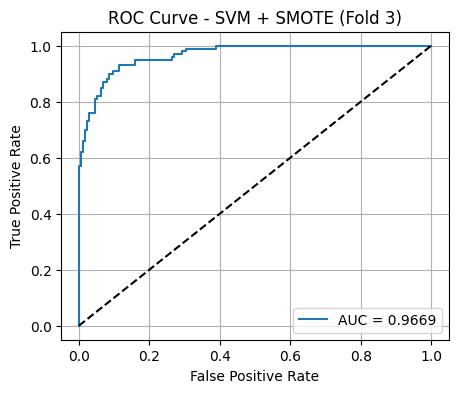

G-Mean : 0.8769

===== SVM + SMOTE | Fold 4 =====
Confusion Matrix:
[[np.int64(168), np.int64(9)], [np.int64(11), np.int64(89)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9385    0.9492    0.9438       177
     Positif     0.9082    0.8900    0.8990       100

    accuracy                         0.9278       277
   macro avg     0.9234    0.9196    0.9214       277
weighted avg     0.9276    0.9278    0.9276       277



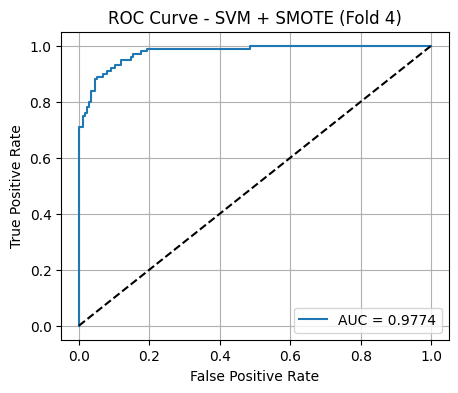

G-Mean : 0.9191

===== SVM + SMOTE | Fold 5 =====
Confusion Matrix:
[[np.int64(170), np.int64(7)], [np.int64(14), np.int64(86)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9239    0.9605    0.9418       177
     Positif     0.9247    0.8600    0.8912       100

    accuracy                         0.9242       277
   macro avg     0.9243    0.9102    0.9165       277
weighted avg     0.9242    0.9242    0.9235       277



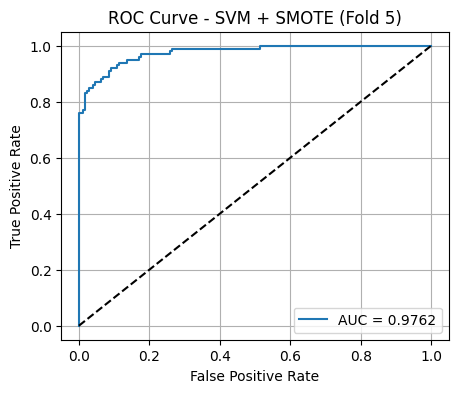

G-Mean : 0.9088

===== SVM + SMOTE | Fold 6 =====
Confusion Matrix:
[[np.int64(161), np.int64(16)], [np.int64(6), np.int64(94)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9641    0.9096    0.9360       177
     Positif     0.8545    0.9400    0.8952       100

    accuracy                         0.9206       277
   macro avg     0.9093    0.9248    0.9156       277
weighted avg     0.9245    0.9206    0.9213       277



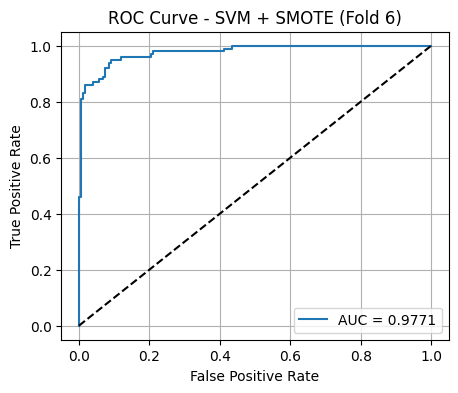

G-Mean : 0.9247

===== SVM + SMOTE | Fold 7 =====
Confusion Matrix:
[[np.int64(167), np.int64(10)], [np.int64(10), np.int64(90)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9435    0.9435    0.9435       177
     Positif     0.9000    0.9000    0.9000       100

    accuracy                         0.9278       277
   macro avg     0.9218    0.9218    0.9218       277
weighted avg     0.9278    0.9278    0.9278       277



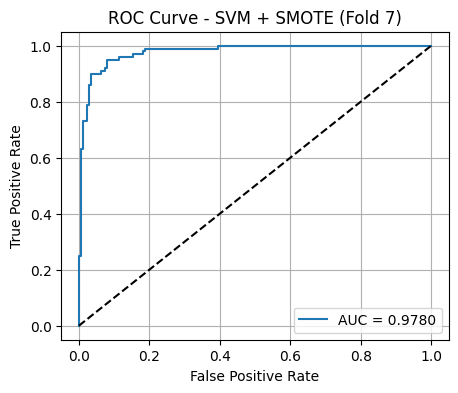

G-Mean : 0.9215

===== SVM + SMOTE | Fold 8 =====
Confusion Matrix:
[[np.int64(170), np.int64(8)], [np.int64(11), np.int64(88)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9392    0.9551    0.9471       178
     Positif     0.9167    0.8889    0.9026        99

    accuracy                         0.9314       277
   macro avg     0.9279    0.9220    0.9248       277
weighted avg     0.9312    0.9314    0.9312       277



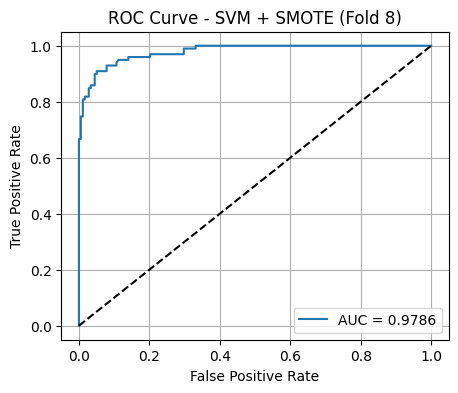

G-Mean : 0.9214

===== SVM + SMOTE | Fold 9 =====
Confusion Matrix:
[[np.int64(165), np.int64(13)], [np.int64(11), np.int64(88)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9375    0.9270    0.9322       178
     Positif     0.8713    0.8889    0.8800        99

    accuracy                         0.9134       277
   macro avg     0.9044    0.9079    0.9061       277
weighted avg     0.9138    0.9134    0.9135       277



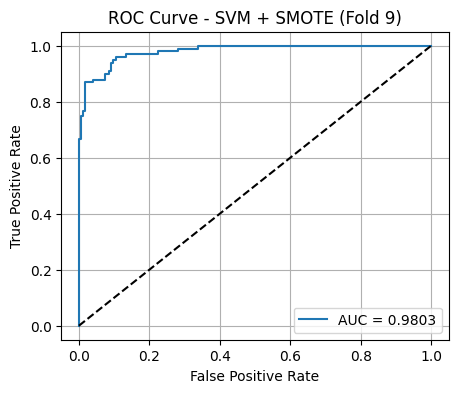

G-Mean : 0.9077

===== SVM + SMOTE | Fold 10 =====
Confusion Matrix:
[[np.int64(166), np.int64(12)], [np.int64(11), np.int64(88)]]

Classification Report:
              precision    recall  f1-score   support

     Negatif     0.9379    0.9326    0.9352       178
     Positif     0.8800    0.8889    0.8844        99

    accuracy                         0.9170       277
   macro avg     0.9089    0.9107    0.9098       277
weighted avg     0.9172    0.9170    0.9171       277



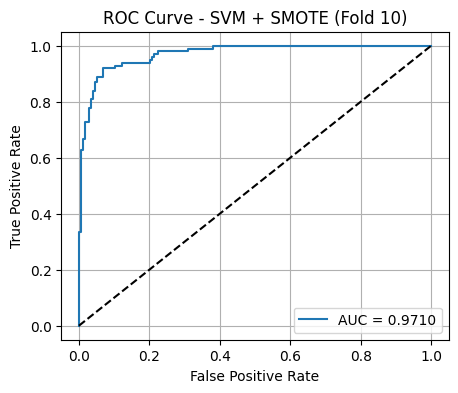

G-Mean : 0.9105


In [ ]:
from imblearn.over_sampling import SMOTE

cm_list_after, auc_list_after, gmean_list_after = [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_text, y), 1):
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

    model = LinearSVC(random_state=42, max_iter=5000)
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_tfidf)
    y_score = model.decision_function(X_test_tfidf)

    cm, auc, gmean = evaluate_fold(
        y_test, y_pred, y_score, fold, "SVM + SMOTE"
    )

    cm_list_after.append(cm)
    auc_list_after.append(auc)
    gmean_list_after.append(gmean)


In [ ]:
avg_cm_before = np.mean(cm_list_before, axis=0)
avg_cm_after  = np.mean(cm_list_after, axis=0)

print("\n=== CONFUSION MATRIX RATA-RATA ===")
print("SVM Tanpa SMOTE:")
print(avg_cm_before.astype(int))

print("\nSVM + SMOTE:")
print(avg_cm_after.astype(int))



=== CONFUSION MATRIX RATA-RATA ===
SVM Tanpa SMOTE:
[[168   9]
 [ 12  86]]

SVM + SMOTE:
[[167  10]
 [ 11  88]]


In [ ]:
print("\n=== RATA-RATA METRIK (5-FOLD CV) ===")
print(f"SVM Tanpa SMOTE → AUC: {np.mean(auc_list_before):.4f}, G-Mean: {np.mean(gmean_list_before):.4f}")
print(f"SVM + SMOTE    → AUC: {np.mean(auc_list_after):.4f}, G-Mean: {np.mean(gmean_list_after):.4f}")



=== RATA-RATA METRIK (5-FOLD CV) ===
SVM Tanpa SMOTE → AUC: 0.9778, G-Mean: 0.9081
SVM + SMOTE    → AUC: 0.9772, G-Mean: 0.9134


## **Save Model**

**Note**:   
Walaupun sebenarnya model yang baru saja di evaluasi bisa saja di save dan digunakan, akan tetapi akan lebih baik untuk train ulang modelnya dengan keseluruhan dataset sebagai train set.
*Dalam notebook ini saya belum mentrain ulang datanya

In [ ]:
import joblib

# Save the trained model
joblib.dump(svm_after, 'svm_smote_model.joblib')

['svm_smote_model.joblib']

In [ ]:
import joblib

# Save TfidfVectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


# **Testing Model**

## **Import Model**

In [ ]:
import joblib

# Load the saved model
svm_smote_model = joblib.load('svm_smote_model.joblib')

print("Model loaded successfully!")

Model loaded successfully!


## **Uji Data Baru (Input Text)**

In [ ]:
# --- Sekarang, mari kita gunakan model yang sudah dimuat untuk memprediksi sentimen untuk teks baru ---

# Dapatkan input teks baru dari pengguna
new_input_text = input("Masukkan teks baru untuk prediksi: ")

# Praproses teks baru menggunakan fungsi yang telah didefinisikan sebelumnya
# (Pastikan 'kamus_tidak_baku' dan fungsi praproses lainnya berada dalam cakupan)
preprocessed_input_text = preprocess_full_text(new_input_text, kamus_tidak_baku)

print(f"Teks setelah preprocessing: {preprocessed_input_text}")

# Transformasi teks yang telah diproses menggunakan vektorisasi TF-IDF yang telah diprogram sebelumnya
# (Pastikan 'vektorisasi' berada dalam cakupan, yaitu, sel TF-IDF telah dijalankan sebelumnya atau bisa juka pake model TF-IDF yang telah di save)
input_text_vec = vectorizer.transform([preprocessed_input_text])

# # Prediksi sentimen menggunakan model yang telah dimuat
predicted_sentiment = svm_smote_model.predict(input_text_vec)

print(f"Prediksi sentimen untuk teks baru: {predicted_sentiment[0]}")


Masukkan teks baru untuk prediksi: aplikasi sering error dan server sering sekali busy
Teks setelah preprocessing: aplikasi error server busy
Prediksi sentimen untuk teks baru: Negatif


In [ ]:
#Tidak menggunakan preprocess

# new_text = input("Masukkan teks baru: ")
# new_text_vec = vectorizer.transform([new_text])
# predicted_sentimen = svm_after.predict (new_text_vec)

# print("Prediksi sentimen: ", predicted_sentimen[0])

Masukkan teks baru: banget
Prediksi sentimen:  Positif


## **Function untuk Preprocessing**

In [ ]:
!pip install Sastrawi
!pip install --upgrade thinc spacy

  Using cached thinc-9.1.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached blis-1.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.6 kB)


In [ ]:
import re
import string
import nltk
import pandas as pd
import spacy
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


# Ensure nlp model is loaded and pipeline is set up
try:
  nlp = spacy.load("xx_ent_wiki_sm")
except:
  !python -m spacy download xx_ent_wiki_sm
  nlp = spacy.load("xx_ent_wiki_sm")
# Only add 'sentencizer' if it's not already in the pipeline
if 'sentencizer' not in nlp.pipe_names:
    nlp.add_pipe('sentencizer')

# Initialize Indonesian stemmer from Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Download stopwords if not already downloaded
try:
    stop_words = nltk.corpus.stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')
    stop_words = nltk.corpus.stopwords.words('indonesian')

# Load kamus_tidak_baku (assuming it's available in the environment or needs to be reloaded)
# For robustness, we can load it here or ensure it's a global variable
kamus_data = pd.read_excel('/content/drive/MyDrive/kamuskatabaku.xlsx') # Uncomment if kamus_tidak_baku is not global
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku'])) # Uncomment if kamus_tidak_baku is not global

# Re-define or ensure access to previously defined functions
def remove_emoji(text):
    if text is not None and isinstance(text, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # geometric shapes extended
            u"\U0001F800-\U0001F8FF"  # supplemental arrows
            u"\U0001F900-\U0001F9FF"  # pictographs
            u"\U0001FA00-\U0001FA6F"  # chess symbols
            u"\U0001FA70-\U0001FAFF"  # extended symbols
            u"\U0001F004-\U0001F0CF"  # card symbols
            u"\U0001F1E0-\U0001F1FF"  # flags
            "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', text)
    return text

def remove_symbols(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

def remove_numbers(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'\d+', '', text)
    return text

def remove_usernames(text):
    return re.sub(r'@[^\s]+', '', text)

def remove_extra_spaces(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'\s+', ' ', text).strip()
    return text

def case_folding(text):
  if isinstance(text, str):
    lowercase_text = text.lower()
    return lowercase_text
  else:
    return text

def normalize_nonstandard_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        normalized_words = []

        for word in words:
            if word in kamus_tidak_baku:
                corrected_word = kamus_tidak_baku[word]
                if isinstance(corrected_word, str) and all(char.isalpha() or char.isspace() for char in corrected_word):
                    normalized_words.append(corrected_word)
                else:
                    normalized_words.append(word)
            else:
                normalized_words.append(word)

        final_text = ' '.join(normalized_words)
    else:
        final_text = ''
    return final_text

def tokenize(text):
  if isinstance(text, str):
    tokens = text.split()
    return tokens
  return []

def remove_stopwords(token_list):
  if isinstance(token_list, list):
    return [word for word in token_list if word not in stop_words]
  return []

def apply_stemming(token_list):
    if isinstance(token_list, list):
        return [stemmer.stem(word) for word in token_list]
    return []

def preprocess_full_text(text, kamus_tidak_baku):
    # Cleaning
    cleaned_text = remove_emoji(text)
    cleaned_text = remove_symbols(cleaned_text)
    cleaned_text = remove_numbers(cleaned_text)
    cleaned_text = remove_usernames(cleaned_text)
    cleaned_text = remove_extra_spaces(cleaned_text)

    # Case Folding
    case_folded_text = case_folding(cleaned_text)

    # Normalization
    normalized_text = normalize_nonstandard_words(case_folded_text, kamus_tidak_baku)

    # Tokenizing
    tokenized_text = tokenize(normalized_text)

    # Stopword Removal
    stopword_removed_text = remove_stopwords(tokenized_text)

    # Stemming
    stemmed_text = apply_stemming(stopword_removed_text)

    return ' '.join(stemmed_text)

print("Function `preprocess_full_text` defined successfully!")

Function `preprocess_full_text` defined successfully!


## **Analisis Sentimen Model SVM + SMOTE**


=== Distribusi Sentimen ===
Positif    1277
Negatif    1852
Name: count, dtype: int64


/tmp/ipython-input-1853239711.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pred_count_series.index, y=pred_count_series.values, palette={'Positif': 'skyblue', 'Negatif': 'salmon'})


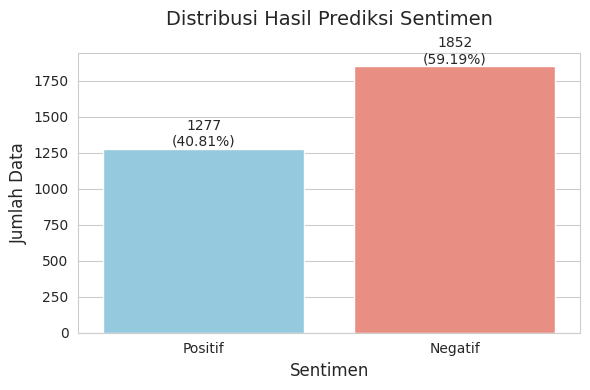

In [ ]:
#Ini pakai yang "stemmed"

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# === 1. Load dataset and take only the 'sentence' column ===
data = pd.read_excel('/content/drive/MyDrive/data_label2_baru.xlsx')

sentences = data['stemmed'].fillna('').tolist()

# === 2. Transform sentences using fitted TF‑IDF vectorizer ===
sentences_vec = vectorizer.transform(sentences)  # vectorizer harus sudah di train sebelumnya

# === 3. Predict sentiment using the trained SVM (svm_smote_model) ===
predictions = svm_smote_model.predict(sentences_vec)

data['predicted_sentiment'] = predictions

# === 4. Show prediction distribution with percentages ===
pred_count_series = pd.Series(predictions).value_counts().reindex(['Positif', 'Negatif'])
print("\n=== Distribusi Sentimen ===")
print(pred_count_series)

plt.figure(figsize=(6, 4))
sns.set_style('whitegrid')
ax = sns.barplot(x=pred_count_series.index, y=pred_count_series.values, palette={'Positif': 'skyblue', 'Negatif': 'salmon'})

plt.title('Distribusi Hasil Prediksi Sentimen', fontsize=14, pad=20)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)

total = pred_count_series.sum()

for i, count in enumerate(pred_count_series.values):
  percentage = f'{100 * count / total:.2f}%'
  ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Tampilkan beberapa baris pertama dari DataFrame gabungan
data[['sentence','stemmed', 'predicted_sentiment']].head(10)

,sentence,stemmed,predicted_sentiment
0,bagus bagus bagus,bagus bagus bagus,Negatif
1,DeepSeek hebat luar biasa ðŸ™ðŸ™ðŸ‘ðŸ‘â™¥ï¸,deepseek hebat,Negatif
2,Very Bad AI stupid AI Merasa Paling Benar Sendiri,very bad ai stupid ai,Negatif
3,"Halo Deepseek, Tolong diperbaiki dan tingkatka...",halo deepseek tolong baik tingkat respon hasil...,Positif
4,sangat membantu,bantu,Negatif
5,Tambahkan bahasa indonesia æ·»åŠ å°å°¼è¯­ï¼Œè...,tambah bahasa indonesia,Negatif
6,"sangat membantu dan literasinya komplit, terim...",bantu literasinya komplit terimakasih,Positif
7,mengharapkan agar deepseek ke depan nya lebih ...,harap deepseek ya kalah upgrade aplikasi,Negatif
8,dan tolong ... privasi user ... tetap dijaga (...,tolong privasi user jaga komitmen developer user,Negatif
9,deep seek ai paling mantap yg saya pake karena...,deep seek ai mantap pakai ajar ilmu gampang,Positif


In [ ]:
#Simpan DataFrame ke file excel
data.to_excel('data_predicted_sentiment.xlsx', index=False)

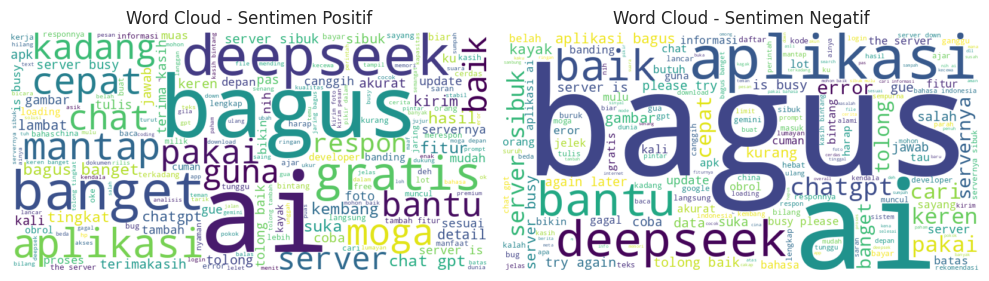

In [ ]:
!pip install wordcloud matplotlib

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Custom stopwords for positive and negative word clouds
positive_stopwords = {"ya", "sih"}  # example words to exclude
negative_stopwords = {"ya", "sih"}   # example words to exclude

# Filter data for positive and negative sentiments using the 'label' column
positive_reviews = data[data['predicted_sentiment'] == 'Positif']
negative_reviews = data[data['predicted_sentiment'] == 'Negatif']

# Combine the 'stemmed' text for each sentiment
positive_text = " ".join(review for review in positive_reviews['stemmed'].dropna())
negative_text = " ".join(review for review in negative_reviews['stemmed'].dropna())

# Generate Word Cloud for Positive Reviews with custom stopwords
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', stopwords=positive_stopwords).generate(positive_text)

# Generate Word Cloud for Negative Reviews with custom stopwords
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', stopwords=negative_stopwords).generate(negative_text)

# Display the generated word clouds
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Sentimen Positif')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Sentimen Negatif')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from collections import Counter

# Tokenize and filter stopwords
positive_tokens = [word for word in positive_text.split() if word.lower() not in positive_stopwords]
negative_tokens = [word for word in negative_text.split() if word.lower() not in negative_stopwords]

# Count word frequencies
positive_counts = Counter(positive_tokens)
negative_counts = Counter(negative_tokens)

# Create DataFrames
df_positive_freq = pd.DataFrame(positive_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)
df_negative_freq = pd.DataFrame(negative_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

print("Top Positive Words:")
print(df_positive_freq.head(20))

print("\nTop Negative Words:")
print(df_negative_freq.head(20))

Top Positive Words:
         Word  Frequency
7          ai        368
9       bagus        284
61     banget        203
24     server        183
1    deepseek        141
25       chat        135
3        baik        112
2      tolong         95
53     gratis         94
58       moga         89
15   aplikasi         88
125     sibuk         88
19      fitur         82
38     mantap         81
28      cepat         77
137    kadang         74
32      bantu         70
39      pakai         70
88      kirim         70
136      busy         67

Top Negative Words:
          Word  Frequency
0        bagus        345
14    aplikasi        300
5           ai        296
58      server        268
54        baik        166
1     deepseek        133
46       sibuk        132
7        bantu        123
300       busy        114
15      tolong        112
48     chatgpt         91
78       pakai         90
238       cari         81
45   servernya         77
43       keren         73
27      banget    

## **Uji Data Baru (20 Ulasan DeepSeek)**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

# === 1. Load dataset ===
data = pd.read_excel('/content/drive/MyDrive/test_data_baru_deepseek.xlsx')

# === 2. Preprocess the new text using the defined function
data['ulasan_preprocessed'] = data['Ulasan'].apply(lambda x: preprocess_full_text(x, kamus_tidak_baku))

# === 3. Transform preprocessed texts using fitted TF‑IDF vectorizer ===
sentences_vec = vectorizer.transform(data['ulasan_preprocessed'])  # vectorizer must already be trained earlier

# === 4. Predict sentiment using the trained SVM (svm_after) ===
predictions = svm_smote_model.predict(sentences_vec)

data['predicted_sentiment'] = predictions

# === 5. Display prediction results ===
data.head(21)

,Ulasan,Tanggal,ulasan_preprocessed,predicted_sentiment
0,aplikasi gak berguna .,2025-11-18,aplikasi guna,Negatif
1,1. respon terkadang sangat lamban 2. tiba-tiba...,2025-11-15,respon terkadang lamban tibatiba bahasa china ...,Negatif
2,ai yg menyesatkan.. hanya memberi jawaban mend...,2025-11-13,ai sesat duga duga tau jebak aku tau,Negatif
3,"Ai paling bagus yang pernah kutemui, sudahlah ...",2025-11-13,ai bagus temu gratis responnya cepat kirim fot...,Positif
4,"Sangat membantu, ai yang asik dan seru jika di...",2025-11-10,bantu ai asik seru ajak cerita obrol,Positif
5,aplikasinya bermanfaat bangettt,2025-11-09,aplikasi manfaat banget,Positif
6,sangat membantu dan penyampaian nya sangat det...,2025-11-09,bantu sampai ya detail gantung bagaimanasangat...,Positif
7,"kurang updated secara real time, ditanya harga...",2025-11-04,updated real time harga emas hari updated agne...,Negatif
8,"aplikasi pintar dan cerdas, dengan penjelasan ...",2025-10-26,aplikasi pintar cerdas jelas detail gratis nil...,Positif
9,bagus banget,2025-10-25,bagus banget,Positif


In [ ]:
#Simpan DataFrame ke file excel
data.to_excel('data_baru_predicted_sentiment.xlsx', index=False)

# **Streamlit App**

Untuk aplikasi klasifikasi/analisis sentimen dengan Streamlit bisa kunjungi link berikut: https://github.com/farhanfdlh/sentiment-analysis-app
